# Localizing and Disentangling High-level Concepts

In this notebook, we introduce localization methods that isolate individual high-level concepts by mapping model activations into a more monosemantic feature space.


---

## The disentanglement problem

A central goal of interpretability is to localize an abstract concept to a component of a deep learning model. For example, when a language model processes the prompt `Paris is the capital of` and outputs `France`, *where* in the model is the `country` attribute represented?

This requires a bit more effort than selecting a residual stream representation, as we did in the previous lectures. We know that information about the entity, including its attribute values, is localized in the residual stream at the last entity token, but that same residual stream vector might also encode Pairs's continent (Europe), language (Franch), timezone (France/Paris), and so on.

What about just selecting a few dimensions of the residual stream? It surely would work better than using the full vector, but that assumes each high-level concept is aligned with a disjoint set of neurons in the model. Unfortunately, neurons in language models are often **polysemantic** — they represent multiple high-level concepts. For example, a neuron that activates on the country attribute might also activate on the continent attribute, making it hard to disentangle the two concepts. The polysemantic nature suggests that in order to disentangle high-level concepts, we might need to map model representations into a new feature space. 

**The problem**: Can an interpretability method find a **feature** (a direction, subspace, or sparse code) in the activations that specifically controls one attribute — e.g., city → country — while leaving the model's representations of all other attributes (continent, language, timezone) intact?


---

## What we cover in this notebook

1. Introducing the entity-attribute disentanglement task and the causal model
2. Problems with localizing using full vector patching
3. Selecting neurons using Differential Binary Masking (DBM)
4. Learning feature mapping through Distributed Alignment Search (DAS)
5. Disentangling through Multi-task DAS (MDAS)

## 1. The entity-attribute disentanglement task and the causal model


### The entity-attribute disentanglement task

We will use the disentanglement task from the [RAVEL](https://github.com/explanare/ravel) benchmark, which consists of simple factual knowledge retrieval prompts that we have worked with in previous notebooks, i.e., given an entity and an attribute, retrieve the attribute value.

**Objective**: The task objective is to localize and disentangle different attributes of an entity. For example, we are interested in localizing the `continent` attribute of a city.

**Metrics**: How do we know if our localization is successful? We apply interchange interventions on the localized representations and measure the **causal effects** of our interventions on two types of prompts.
* **Cause**: For prompts that query for the target concept `continent`, the model output should change to the source attribute value after the intervention. This is the same objective as we have seen in the causal abstraction/causal mediation analysis.
* **Isolate**: For prompts that query for all other attributes, the model output should remain unchanged. This is a new objective that ensures disentanglement.

---

Here is a concrete example, as shown in Figure 1. Consider two prompts that retrieve different attributes of the same entity `Paris`. The first one test the **Cause** critiron, as the query is about `continent`, while the second one test the **Isolate** critiron, as the query is about `country`.
```
Base:
      Cause:   Paris is in the continent of → Europe
      Isolate: Paris is in the country of → France
```
Now, if we consider a source prompt containing the entity Tokyo, for example:
```
Source:
      Tokyo is a large city
```
The desired causal effects upon interchange interventions between the causal base example and the source example is the output changed from Europe to Asia, while for the isolate base example and the source example, the base output France should remain unchanged.

```
Expected outputs after interventions on the continent feature:
      Paris is in the continent of → Asia    ✓  Cause: Output changed to source attribute value
      Paris is in the country of → France    ✓  Isolate: Output preserved
```



![Figure 1: RAVEL disentanglement task overview](https://raw.githubusercontent.com/explanare/ravel/refs/heads/main/figures/ravel-overview.svg)




### The causal model

We model the entity-attribute retrieval computation as a 3-variable causal model:

```
entity  ──┐
          |
          └──► value
          |
attribute ┘
```

| Variable | High-level Concept | Example |
|---|---|---|
| `entity` | The city being queried (input) | `"Paris"` |
| `attribute` | The attribute to retrieve | `"country"` |
| `value` | The output value  | `"France"` |

This causal structure specifies that `entity` and `attribute` are **independent inputs** that jointly determine `value`.
For disentanglement, we target the `entity` variable.

In [ ]:
#@title Setup

%load_ext autoreload
%autoreload 2

# Add library paths.
import sys

CAUSALAB_DIR = "causalab-internal"

sys.path.append(CAUSALAB_DIR)
sys.path.append('pyvene')

In [ ]:
%%bash

# Usage:                                                                                                                                                                                                           
python 01_generate_and_filter_dataset.py \
    --model allenai/OLMo-2-0425-1B \
    --output-dir ravel_exp

In [4]:
# Output of 01_generate_and_filter_dataset.py
import json
import os
from IPython.display import display

cause_data = json.load(open(os.path.join(CAUSALAB_DIR, "ravel_exp/cause_country/train_dataset.json")))
isolate_data = json.load(open(os.path.join(CAUSALAB_DIR, "ravel_exp/isolate_country/train_dataset.json")))

display(cause_data[0])
display(isolate_data[0])

{'input': {'entity': 'Stockholm',
  'attribute': 'country',
  'raw_input': 'Stockholm is in the country of',
  'value': 'Sweden',
  'raw_output': ' Sweden'},
 'counterfactual_inputs': [{'entity': 'Barcelona',
   'attribute': None,
   'raw_input': 'Barcelona is a large city',
   'value': 'UNKNOWN_VALUE',
   'raw_output': ' UNKNOWN_VALUE'}]}

{'input': {'entity': 'Zurich',
  'attribute': 'continent',
  'raw_input': 'Zurich is in the continent of',
  'value': 'Europe',
  'raw_output': ' Europe'},
 'counterfactual_inputs': [{'entity': 'Montreal',
   'attribute': None,
   'raw_input': 'Montreal is a large city',
   'value': 'UNKNOWN_VALUE',
   'raw_output': ' UNKNOWN_VALUE'}]}

## 2. Problems with using full-vector patching

Let's start with the simple localization method we learned in previous lectures, i.e., patching the **entire residual stream vector** at a given (layer, token position).

Consider the residual stream representation of the entity token `Paris` at some layer. This single vector implicitly encodes answers to many questions:

- country → France
- continent → Europe  
- latitude → 48
- timezone → Europe/Paris
- ...

If we apply an interchange intervention — patching the residual stream at the Paris token with the residual stream from a Tokyo prompt — the model might output `Asia` for continent. But does it now also output `Japan` for country? If so, the intervention has **entangled** both attributes.

Now we can come up with our hypothesis and test it out.

**Hypothesis**: A raw residual-stream patch scores well on Cause but poorly on Isolate, because swapping the full activation vector changes everything at once.

In [ ]:
%%bash

#  Usage:                                                                                                                                                                                                           
python 02_run_full_vector_patching.py --model allenai/OLMo-2-0425-1B \                                                                                                                                           
    --cause-test-dataset ravel_exp/cause_country/test_dataset.json \                                                                                                                                             
    --isolate-test-dataset ravel_exp/isolate_country/test_dataset.json \                                                                                                                                         
    --output-dir ravel_exp/full_vector_country                                                                                                                                                                 

# Visualize all three heatmaps:                                                                                                                                                                                                                
python 00_compute_scores_and_visualize.py \
    --results ravel_exp/full_vector_country/cause/raw_results.pkl \                                                                                                                                              
    --isolate-results ravel_exp/full_vector_country/isolate/raw_results.pkl \                                                                                                                                  
    --output-dir full_vector_viz 

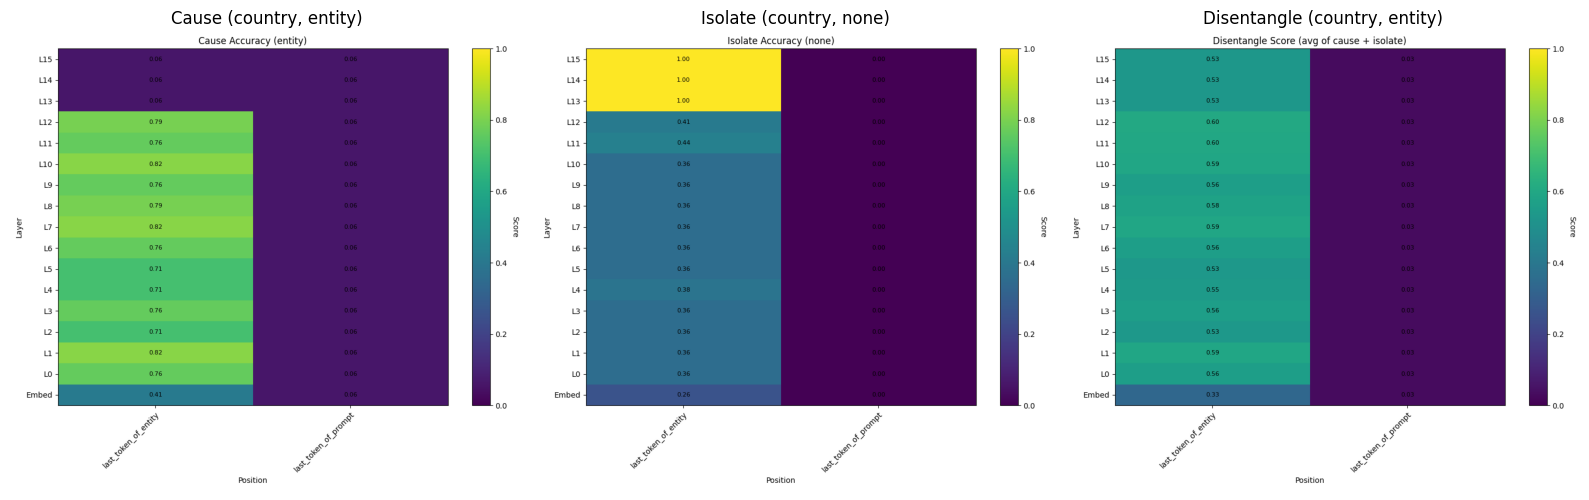

In [5]:
# Display the heatmap at full_vector_viz/heatmaps/cause_country_entity_heatmap.png
# and full_vector_viz/heatmaps/isolate_country_none_heatmap.png side by side

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

heatmaps_dir = Path(CAUSALAB_DIR) / "full_vector_viz/heatmaps"
paths = [
    heatmaps_dir / "cause_country_entity_heatmap.png",
    heatmaps_dir / "isolate_country_none_heatmap.png",
    heatmaps_dir / "disentangle_heatmap.png",
]
titles = ["Cause (country, entity)", "Isolate (country, none)", "Disentangle (country, entity)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, path, title in zip(axes, paths, titles):
    ax.imshow(Image.open(path))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Interpreting the Patching Results

Indeed, we have seen high score in the causal test, but low score on the isolate. Full vector patching is a blunt instrument: when we patch the entity token's activation, we simultaneously change every attribute encoded there (country, continent, language, ...). The model has no opportunity to update only the country.

This motivates the next method, which will select a subset of dimensions instead using the full vectors.

## 3. Differential Binary Masking (DBM)

DBM learns a **binary mask** over the dimensions of a residual stream vector at each (layer, position). Instead of swapping the entire vector (as in full vector patching), DBM selects a minimal subset of the d_model dimensions to patch from source to base. During training the masks are continuous and annealed to binary values, controlled by a sparsity regularization coefficient.

Unlike full vector patching — which swaps every dimension at once — DBM considers all dimensions **jointly**, allowing it to find the minimal sufficient set of neurons. A high train/test accuracy with a small number of selected dimensions is the best outcome.

We train one DBM model per (layer, position) for each scoring objective (cause and isolate), then visualize the results as heatmaps showing accuracy and feature counts across the residual stream.

In [ ]:
%%bash

# Usage:                                                                                                                                                                                                           
python 03_train_dbm.py --model allenai/OLMo-2-0425-1B \                                                                                                                                                          
    --train-dataset ravel_exp/cause_country/train_dataset.json \                                                                                                                                                 
    --cause-test-dataset ravel_exp/cause_country/test_dataset.json \                                                                                                                                             
    --isolate-test-dataset ravel_exp/isolate_country/test_dataset.json \
    --output-dir ravel_exp/dbm_cause_country

# Visualize all three heatmaps:                                                                                                                                                                                  
python 00_compute_scores_and_visualize.py \                                                                                                                                                                      
    --results ravel_exp/dbm_cause_country/cause/raw_results.pkl \                                                                                                                                                
    --isolate-results ravel_exp/dbm_cause_country/isolate/raw_results.pkl \                                                                                                                                      
    --output-dir dbm_viz 


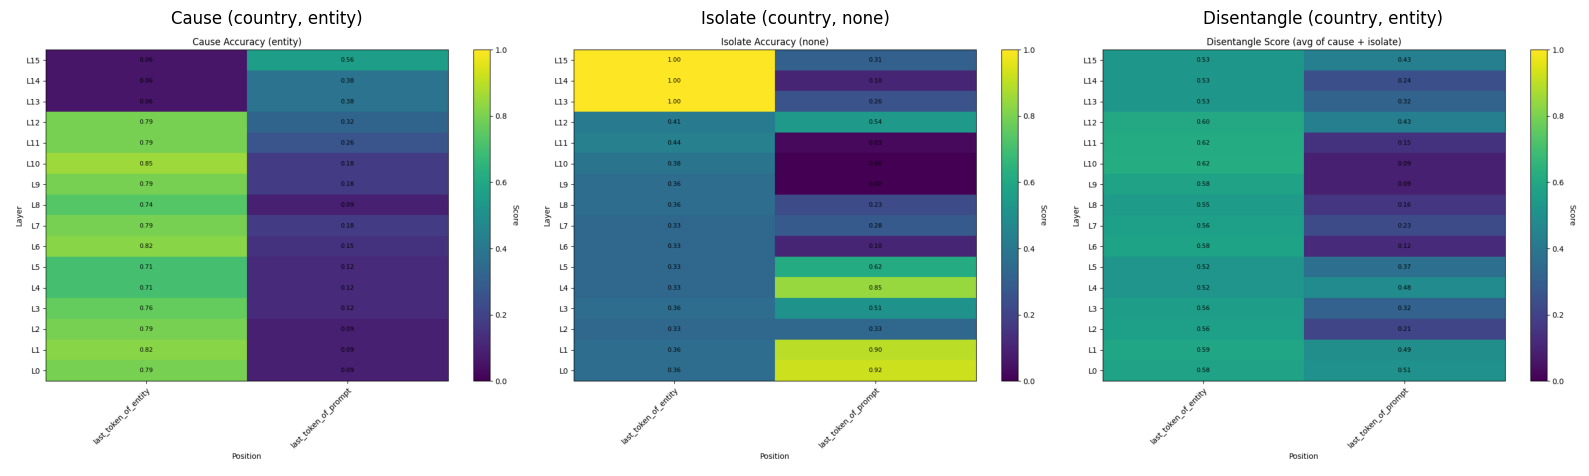

In [6]:
# Display the heatmap at full_vector_viz/heatmaps/cause_country_entity_heatmap.png
# and full_vector_viz/heatmaps/isolate_country_none_heatmap.png side by side

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

heatmaps_dir = Path(CAUSALAB_DIR) / "dbm_viz/heatmaps"
paths = [
    heatmaps_dir / "cause_country_entity_heatmap.png",
    heatmaps_dir / "isolate_country_none_heatmap.png",
    heatmaps_dir / "disentangle_heatmap.png",
]
titles = ["Cause (country, entity)", "Isolate (country, none)", "Disentangle (country, entity)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, path, title in zip(axes, paths, titles):
    ax.imshow(Image.open(path))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Interpreting DBM

DBM learns a binary mask over the **dimensions** of each residual stream vector at a given (layer, position). For each (layer, position), it selects the minimal subset of the d_model dimensions that are causally sufficient for the target variable. This is more fine-grained than full vector patching (which swaps the entire vector).

Key observations:

- **High cause + high isolate accuracy** at a (layer, position) means DBM found a subset of dimensions that carries the target attribute without disturbing other attributes. This is evidence of **neuron-level disentanglement** — different neurons encode different attributes.
- **High cause + low isolate accuracy** means the selected dimensions also carry non-target attributes. The attributes are entangled at the neuron level, and we need DAS to find disentangled *directions* within those dimensions.
- **Few selected dimensions** (high sparsity) with high accuracy is the best outcome — it means the target variable is concentrated in a small, identifiable subset of the representation.

Because DBM selects axis-aligned dimensions (individual neurons), it cannot find disentangled representations that are encoded as **linear combinations** of neurons. For that, we need DAS.

## 4. Distributed Alignment Search (DAS)

DAS learns an **orthonormal rotation matrix** $R$ such that intervening on a small subspace of the rotated features — rather than on the full activation vector — causally mediates the target variable.

Concretely, given activation $h \in \mathbb{R}^d$:
1. **Featurize**: $f = hR^\top$ (rotate into feature space)
2. **Patch**: replace the first $k$ features of the base with those from the source
3. **Invert**: $h' = fR$ (rotate back to activation space)
4. **Optimize**: update $R$ (keeping it orthonormal) so the intervened output matches the causal model

Because $R$ is orthonormal, the first $k$ features can encode the target variable while the remaining $d-k$ features preserve everything else. This provides the potential to disentangle high-level concepts that are distrbuted across neurons.

We run DAS at every (layer, position) independently.

In [ ]:
%%bash

# Usage:                                                                                                                                                                                                           
python 04_train_das.py --model allenai/OLMo-2-0425-1B \                                                                                                                                                          
    --train-dataset ravel_exp/cause_country/train_dataset.json \                                                                                                                                                 
    --cause-test-dataset ravel_exp/cause_country/test_dataset.json \                                                                                                                                             
    --isolate-test-dataset ravel_exp/isolate_country/test_dataset.json \
    --output-dir ravel_exp/das_cause_country                                                                                                                                                                     
                                                                                                                                                                                                                 
# Visualize all three heatmaps:                                                                                                                                                                                  
python 00_compute_scores_and_visualize.py \                                                                                                                                                                      
    --results ravel_exp/das_cause_country/cause/raw_results.pkl \                                                                                                                                                
    --isolate-results ravel_exp/das_cause_country/isolate/raw_results.pkl \                                                                                                                                      
    --output-dir das_viz 

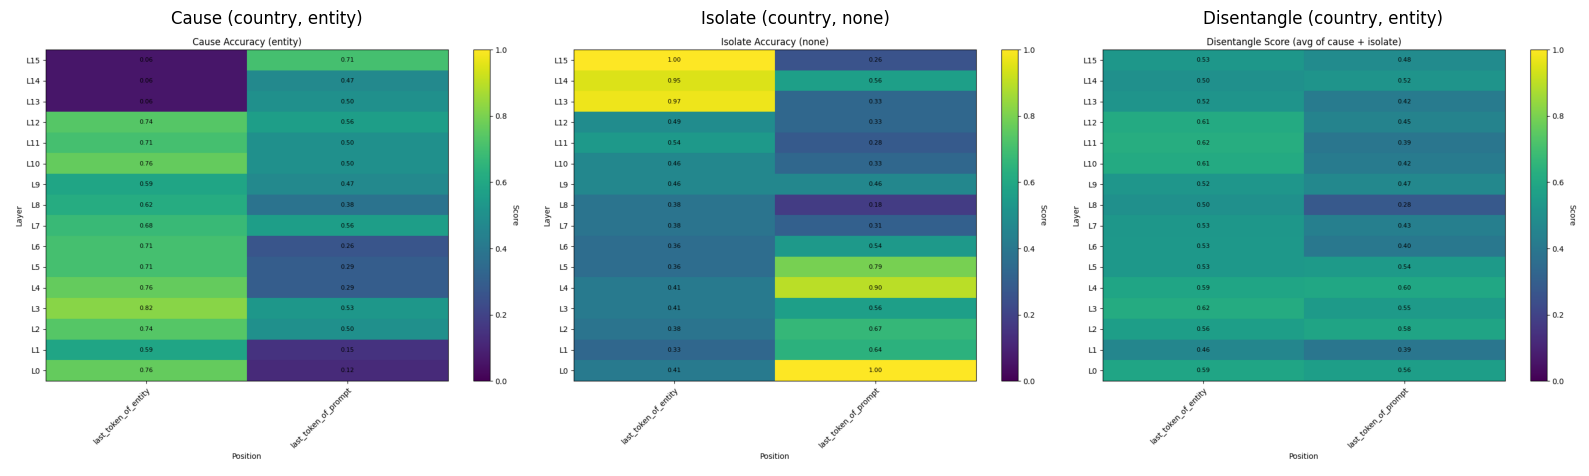

In [7]:
# Display the heatmap at full_vector_viz/heatmaps/cause_country_entity_heatmap.png
# and full_vector_viz/heatmaps/isolate_country_none_heatmap.png side by side

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

heatmaps_dir = Path(CAUSALAB_DIR) / "das_viz/heatmaps"
paths = [
    heatmaps_dir / "cause_country_entity_heatmap.png",
    heatmaps_dir / "isolate_country_none_heatmap.png",
    heatmaps_dir / "disentangle_heatmap.png",
]
titles = ["Cause (country, entity)", "Isolate (country, none)", "Disentangle (country, entity)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, path, title in zip(axes, paths, titles):
    ax.imshow(Image.open(path))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Interpreting DAS

Like DBM, we train DAS separately on cause and isolate data and compare the two heatmaps. But unlike DBM — which selects axis-aligned neurons — DAS learns arbitrary **directions** (linear combinations of neurons) via an orthonormal rotation. This means DAS can disentangle attributes even when they share the same neurons.

Key observations:

- **High cause + high isolate accuracy** at a (layer, position) means DAS found a low-dimensional subspace that carries the target attribute without disturbing other attributes. This is the strongest evidence of **directional disentanglement** — the target attribute is encoded in a specific direction within the residual stream, orthogonal to directions encoding other attributes.
- **High cause + low isolate accuracy** means even DAS cannot separate the target attribute from others at this location. The attributes may be entangled in a way that cannot be resolved by a linear rotation — or the subspace dimension (`n_features`) may need adjustment.
- **DAS outperforming DBM** at the same (layer, position) indicates that the attribute is encoded as a distributed pattern across neurons, not aligned with individual neuron axes. This is the typical case in language models due to polysemanticity.
- **DAS matching DBM** suggests the representation happens to be axis-aligned at that location — the neurons are already monosemantic for this attribute.


## 5. Multi-task DAS (MDAS)

Single-attribute DAS trains a separate rotation for cause and isolate. **MDAS** trains a **single shared rotation** that must simultaneously satisfy both objectives by training on a mixture of cause-labeled and isolate-labeled examples.

This is a stricter test: the learned subspace must both:
- **Cause the target attribute to change** when patched (cause examples)
- **Preserve non-target attributes** when patched (isolate examples)

A single rotation $R$ must partition the feature space so that the first $k$ features specifically encode the target attribute, while the remaining $d-k$ features are orthogonal and carry everything else. If the subspace achieves high accuracy on both objectives, the representations are truly disentangled — different directions in the same vector space carry different attributes.

In [ ]:
%%bash

# Usage:                                                                                                                                                                                                           
python 05_train_mdas.py \
    --model allenai/OLMo-2-0425-1B \
    --cause-train-dataset ravel_exp/cause_country/train_dataset.json  \
    --cause-test-dataset ravel_exp/cause_country/test_dataset.json  \
    --isolate-train-dataset ravel_exp/isolate_country/train_dataset.json  \
    --isolate-test-dataset ravel_exp/isolate_country/test_dataset.json \
    --output-dir ravel_exp/mdas_cause_country

# Visualize all three heatmaps:                                                                                                                                                                                  
python 00_compute_scores_and_visualize.py \                                                                                                                                                                      
    --results ravel_exp/mdas_cause_country/cause/raw_results.pkl \                                                                                                                                                
    --isolate-results ravel_exp/mdas_cause_country/isolate/raw_results.pkl \                                                                                                                                      
    --output-dir mdas_viz 

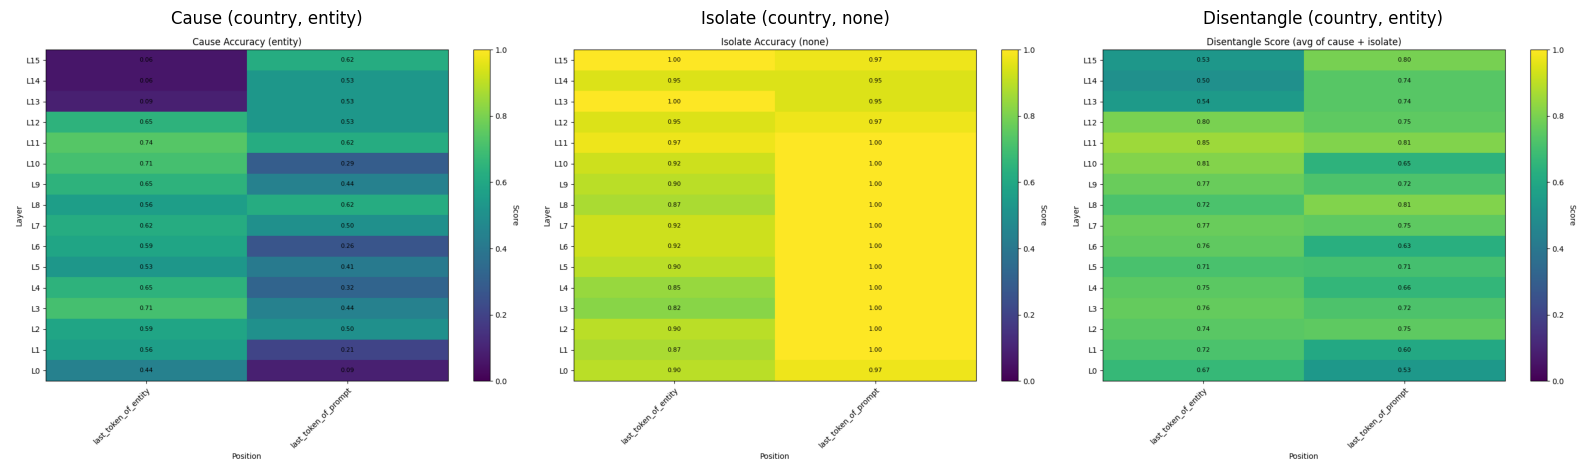

In [10]:
# Display the heatmap at full_vector_viz/heatmaps/cause_country_entity_heatmap.png
# and full_vector_viz/heatmaps/isolate_country_none_heatmap.png side by side

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

heatmaps_dir = Path(CAUSALAB_DIR) / "mdas_viz/heatmaps"
paths = [
    heatmaps_dir / "cause_country_entity_heatmap.png",
    heatmaps_dir / "isolate_country_none_heatmap.png",
    heatmaps_dir / "disentangle_heatmap.png",
]
titles = ["Cause (country, entity)", "Isolate (country, none)", "Disentangle (country, entity)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, path, title in zip(axes, paths, titles):
    ax.imshow(Image.open(path))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Interpreting MDAS

The key result of MDAS is that a single learned subspace can achieve **high cause and high isolate accuracy simultaneously** at the same (layer, position). This is something that previous methods could not achieve:

- **Full vector patching** gets high cause but low isolate — it changes everything.
- **DBM and DAS trained separately** can each score well on their own objective, but those are independent models with no guarantee of consistency. A DAS model trained on cause data might learn a subspace that also disrupts non-target attributes; we just don't test for it during training.

MDAS resolves this by optimizing a single rotation $R$ against both objectives at once. High accuracy on both means the learned $k$-dimensional subspace **specifically encodes the target attribute and nothing else** — patching it transfers the target attribute from source to base (cause) while leaving all other attributes intact (isolate).

Key observations:

- **High cause + high isolate** is the definitive evidence of disentanglement. It means the model's residual stream at this (layer, position) contains an identifiable linear subspace that cleanly separates the target attribute from all others.
- **Locations where MDAS has a lower Cause score than DAS** suggest that the two concepts might not be fully disentanglable, as optimizing for disentanglement reduces causal effects. There might be more complex geometric structures at play, such as one high-level concept is derived from the other.

## 6. Summary

We have applied four progressively more powerful localization methods to the entity attribute disentanglement task:

| Method | What it intervenes on | Disentanglement |
|---|---|---|
| Full vector patching | Entire residual stream vector | None — swaps everything |
| DBM | Binary mask over dimensions per (layer, position) | Neuron-level — selects minimal dimension subset |
| DAS | Learned $k$-dim subspace per (layer, position) | Directional — within a position |
| MDAS | Shared subspace jointly optimized for all variables | Orthogonal directions per variable |

### Key takeaways

1. **Full vector patching** is a useful first pass but cannot distinguish which attributes a residual stream position encodes — it patches all of them at once.

2. **DBM** selects a subset of axis-aligned dimensions (neurons) at each (layer, position) that are causally sufficient for the target variable. High cause + high isolate accuracy means the model has neuron-level disentanglement. High cause + low isolate means the selected neurons also carry other attributes, motivating DAS.

3. **DAS** is more precise than DBM at the same location, because it learns arbitrary directions (linear combinations of neurons) rather than selecting individual neurons. This allows it to find disentangled representations even when attributes are encoded in overlapping sets of neurons.

4. **MDAS** is the most demanding test: a single rotation must simultaneously disentangle all target variables. A high MDAS score at a location where both single-attribute DAS models also score highly is the strongest evidence that the representations are truly disentangled — different directions in the same vector space carry different attributes.